<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 3</h3>
    <h5>Ejercicio 1</h5>
        <p>Docentes: Rodrigo Del Rosso, Braian Drago<p>
        <p><p>
</div>


**Origen de datos**

Datos sobre entradas totales de visitantes a un Parque Nacional con cualquier finalidad

Fuente = https://datos.yvera.gob.ar/series/api/series/?ids=pn_visitantes_total

**Algunos Métodos Simples de Forecasting**

**Importamos las librerías**

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 8.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
import math
from pmdarima import auto_arima

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

**Carga de dataset, adaptación a serie de tiempo, selección de columna a trabajar y visualización**

In [ ]:
url='https://raw.githubusercontent.com/braiandrago/AST/refs/heads/main/serie-tiempo-parques-nacionales-mensual.csv'
dataoriginal = pd.read_csv(url)

In [ ]:
data=dataoriginal.copy()

In [ ]:
data.head()

,indice_tiempo,no_residentes,residentes,total,buenos_aires_no_residentes,buenos_aires_residentes,buenos_aires_total,cordoba_no_residentes,cordoba_residentes,cordoba_total,...,cuyo_total,litoral_no_residentes,litoral_residentes,litoral_total,norte_no_residentes,norte_residentes,norte_total,patagonia_no_residentes,patagonia_residentes,patagonia_total
0,2008-01-01,198407,352303,550710,0,885,885,145,717,862,...,5144,55335,111408,166743,774,4241,5016,141973,230087,372060
1,2008-02-01,151809,283145,434953,0,624,624,148,475,623,...,4942,53596,85853,139449,1294,5099,6393,96632,186291,282923
2,2008-03-01,148533,173134,321667,0,0,0,147,741,888,...,5900,55130,59150,114280,1696,9204,10900,91382,98317,189699
3,2008-04-01,68558,61539,130097,0,462,462,166,539,705,...,1808,30827,23821,54648,728,3867,4595,36759,31121,67879
4,2008-05-01,43751,48787,92538,0,1091,1091,129,608,737,...,2402,29818,28538,58356,663,5083,5746,13038,11169,24206


In [ ]:
data.tail()

,indice_tiempo,no_residentes,residentes,total,buenos_aires_no_residentes,buenos_aires_residentes,buenos_aires_total,cordoba_no_residentes,cordoba_residentes,cordoba_total,...,cuyo_total,litoral_no_residentes,litoral_residentes,litoral_total,norte_no_residentes,norte_residentes,norte_total,patagonia_no_residentes,patagonia_residentes,patagonia_total
163,2021-08-01,380,137039,137419,4,1405,1409,3,1195,1198,...,1091,142,60500,60642,136,14254,14390,91,58598,58689
164,2021-09-01,229,163297,163526,2,1077,1079,9,1377,1386,...,1216,142,71173,71315,5,9669,9674,70,78786,78856
165,2021-10-01,1830,269601,271431,0,2008,2008,17,2076,2093,...,2302,1466,111278,112744,11,24718,24729,332,127223,127555
166,2021-11-01,12337,256047,268384,0,1179,1179,8,683,691,...,17,6290,99745,106035,93,16965,17058,5946,137458,143404
167,2021-12-01,25319,280527,305846,3,894,897,7,305,312,...,2116,9746,81749,91495,138,11179,11317,15392,184317,199709


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   indice_tiempo               168 non-null    object
 1   no_residentes               168 non-null    int64 
 2   residentes                  168 non-null    int64 
 3   total                       168 non-null    int64 
 4   buenos_aires_no_residentes  168 non-null    int64 
 5   buenos_aires_residentes     168 non-null    int64 
 6   buenos_aires_total          168 non-null    int64 
 7   cordoba_no_residentes       168 non-null    int64 
 8   cordoba_residentes          168 non-null    int64 
 9   cordoba_total               168 non-null    int64 
 10  cuyo_no_residentes          168 non-null    int64 
 11  cuyo_residentes             168 non-null    int64 
 12  cuyo_total                  168 non-null    int64 
 13  litoral_no_residentes       168 non-null    int64 

In [ ]:
# Convertir 'indice_tiempo' a datetime asegurando que no haya problemas en el formato
data['indice_tiempo'] = pd.to_datetime(data['indice_tiempo'], format='%Y-%m-%d', errors='coerce')

# Establecer 'indice_tiempo' como índice y asegurarse de que esté ordenado
data.set_index("indice_tiempo", inplace=True)
data.sort_index(inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 2008-01-01 to 2021-12-01
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   no_residentes               168 non-null    int64
 1   residentes                  168 non-null    int64
 2   total                       168 non-null    int64
 3   buenos_aires_no_residentes  168 non-null    int64
 4   buenos_aires_residentes     168 non-null    int64
 5   buenos_aires_total          168 non-null    int64
 6   cordoba_no_residentes       168 non-null    int64
 7   cordoba_residentes          168 non-null    int64
 8   cordoba_total               168 non-null    int64
 9   cuyo_no_residentes          168 non-null    int64
 10  cuyo_residentes             168 non-null    int64
 11  cuyo_total                  168 non-null    int64
 12  litoral_no_residentes       168 non-null    int64
 13  litoral_residentes          168 non-null    in

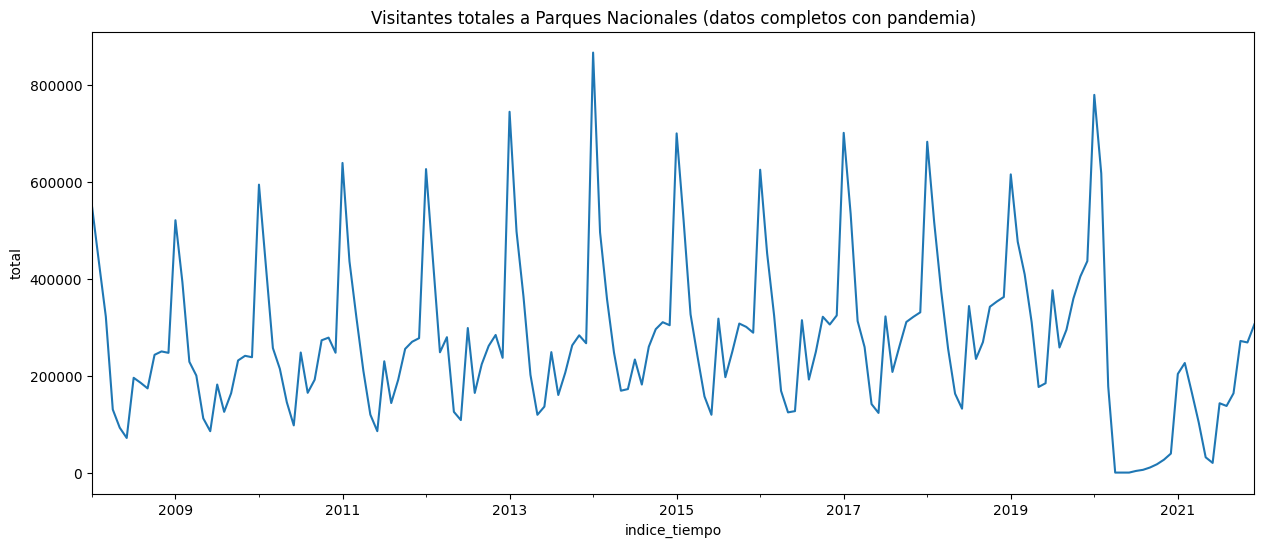

In [ ]:
data["total"].plot(figsize=(15, 6))
plt.xlabel("indice_tiempo")
plt.ylabel("total")
plt.title("Visitantes totales a Parques Nacionales (datos completos con pandemia)")
plt.show()

**Nos quedamos con la historia pre pandemia**

In [ ]:
fechas_a_eliminar = pd.date_range(start="2020-03-01", end="2021-12-01", freq="MS")

# Filtra las fechas a eliminar
data = data[~data.index.isin(fechas_a_eliminar)]

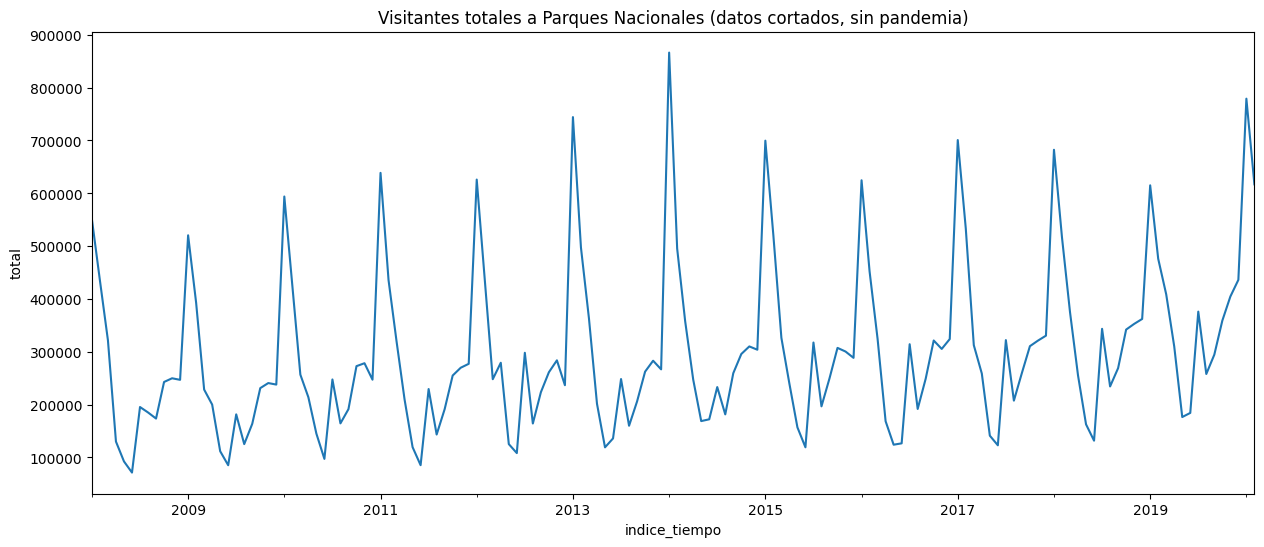

In [ ]:
data["total"].plot(figsize=(15, 6))
plt.xlabel("indice_tiempo")
plt.ylabel("total")
plt.title("Visitantes totales a Parques Nacionales (datos cortados, sin pandemia)")
plt.show()

**Dividimos los datos en conjuntos de entrenamiento y prueba - Teniendo en cuenta las caracteristicas particulares de una serie de tiempo**

In [ ]:
#Divido la serie de tiempo en entrenamiento y testeo ( manteniendo la cronologia )
train_len = len(data)-12 # Base de entrenamiento, total general menos los ultimos 12 periodos
train = data[0:train_len] # Primeros 134 meses para entrenamiento
test = data[train_len:] # Ultimos 12 meses para testeo

In [ ]:
# Divido la serie de tiempo en entrenamiento y testeo
# manteniendo la cronología

train_len = len(data) - 12

train = data.iloc[:train_len].copy()
test = data.iloc[train_len:].copy()

## 1- Average Method (Los pronósticos de todos los valores futuros son iguales al promedio de los datos históricos)

In [ ]:
numerado = train['total'].sum()
denominador = len(train)
resultado = numerado / denominador

In [ ]:
# predicion
test['prediccion_Average_M'] = resultado

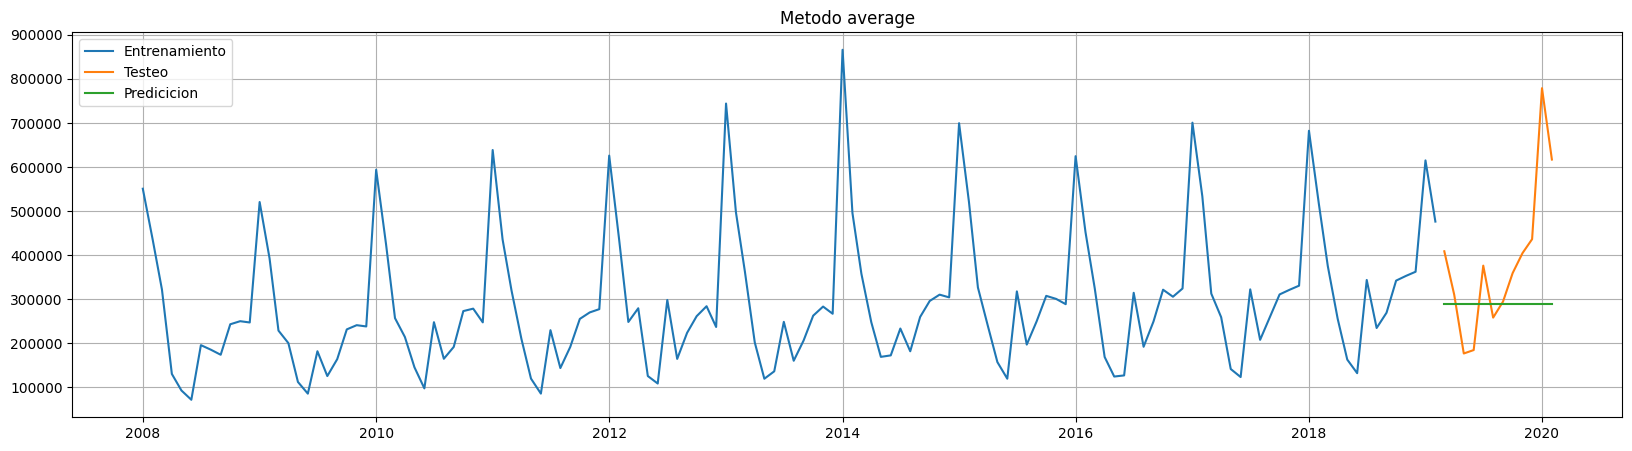

In [ ]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train['total'], label='Entrenamiento')
plt.plot(test['total'], label='Testeo')
plt.plot(test['prediccion_Average_M'], label='Predicicion')
plt.legend(loc='best')
plt.title('Metodo average')
plt.show()

In [ ]:
# metricas del pronostico a analizar posteriormente
MAE_AV_METHOD = mean_absolute_error(test['total'], test['prediccion_Average_M'])
RMSE_AV_METHOD = math.sqrt(MAE_AV_METHOD)
MAPE_AV_METHOD = mean_absolute_percentage_error(test['total'], test['prediccion_Average_M'])

## 2- Naïve Method (Configuramos todos los pronósticos para que sean el valor de la última observación)

In [ ]:
train = data.iloc[:train_len].copy()
test = data.iloc[train_len:].copy()

test['prediccion_Naive_M'] = train['total'].iloc[-1]

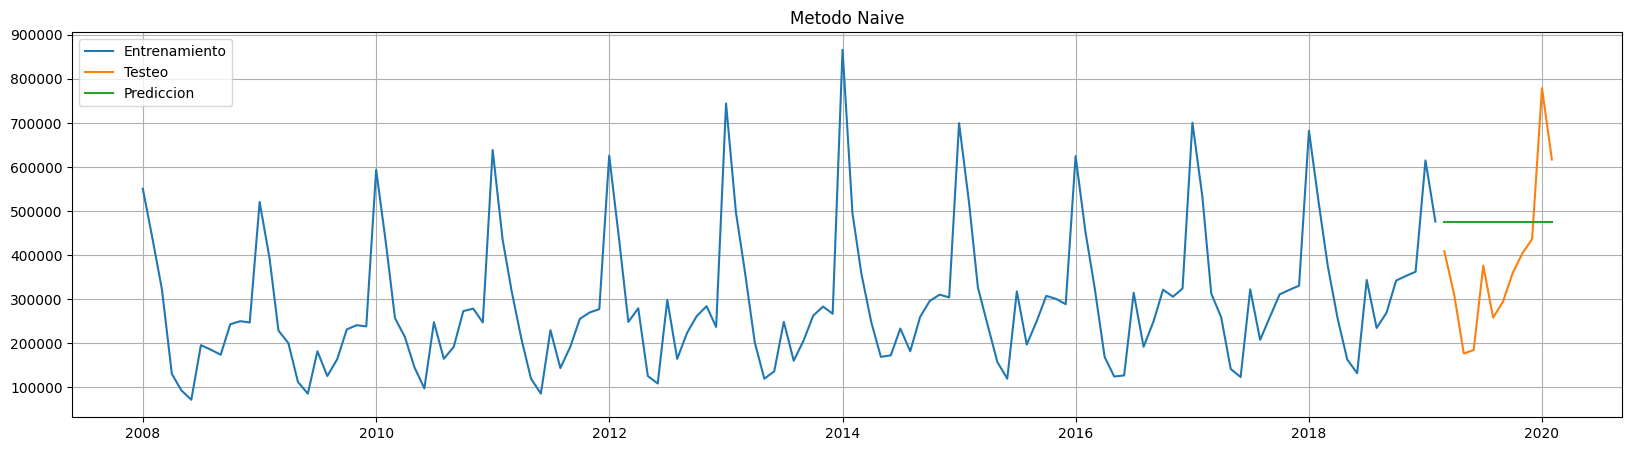

In [ ]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train['total'], label='Entrenamiento')
plt.plot(test['total'], label='Testeo')
plt.plot(test['prediccion_Naive_M'], label='Prediccion')
plt.legend(loc='best')
plt.title('Metodo Naive')
plt.show()

In [ ]:
# metricas del pronostico a analizar posteriormente
MAE_NAIVE_METHOD = mean_absolute_error(test['total'], test['prediccion_Naive_M'])
RMSE_NAIVE_METHOD = math.sqrt(MAE_NAIVE_METHOD)
MAPE_NAIVE_METHOD = mean_absolute_percentage_error(test['total'], test['prediccion_Naive_M'])

## 3- Seasonal Naïve Method (establecemos cada pronóstico para ser igual al último valor observado de la misma estación del año)

In [ ]:
# Método Naive Estacional
seasonal_period = 12  # Serie mensual

# Tomo los últimos 12 meses observados del train
naive_forecast = train['total'].iloc[-seasonal_period:].to_numpy()

# Repito el patrón estacional si el test tiene más de 12 períodos
forecast = np.resize(naive_forecast, len(test))

# Agrego el pronóstico al conjunto de test
test['prediccion_Naive_Estacional'] = forecast

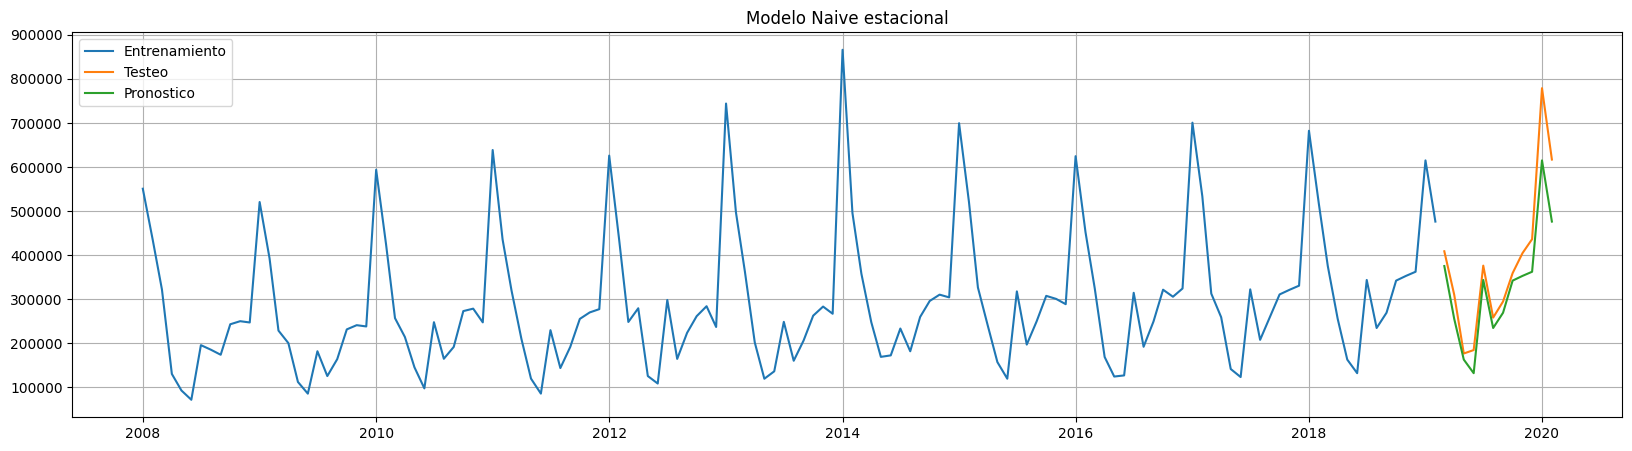

In [ ]:
plt.figure(figsize=(20,5))
plt.grid()
plt.plot(train['total'], label='Entrenamiento')
plt.plot(test['total'], label='Testeo')
plt.plot(test['prediccion_Naive_Estacional'], label='Pronostico')
plt.legend(loc='best')
plt.title('Modelo Naive estacional')
plt.show()

In [ ]:
# metricas del pronostico a analizar posteriormente
MAE_NAIVE_ESTACIONAL_METHOD = mean_absolute_error(test['total'], test['prediccion_Naive_Estacional'])
RMSE_NAIVE_ESTACIONAL_METHOD = math.sqrt(MAE_NAIVE_ESTACIONAL_METHOD)
MAPE_NAIVE_ESTACIONAL_METHOD = mean_absolute_percentage_error(test['total'], test['prediccion_Naive_Estacional'])

## 4- Metodo Drift ( calcula los pronósticos futuros extrapolando una línea recta desde la primera observación hasta la última)  

Proyecta una línea recta basada en el cambio promedio entre el primer y último valor del conjunto de entrenamiento

In [ ]:
# Divido la serie de tiempo en entrenamiento y testeo
# manteniendo la cronología

train_len = 134

train = data.iloc[:train_len].copy()
test = data.iloc[train_len:].copy()


# =========================
# MÉTODO DRIFT
# =========================

# Primer y último valor del conjunto de entrenamiento
y_1 = train['total'].iloc[0]
y_T = train['total'].iloc[-1]

# Pendiente promedio entre el primer y último dato observado
m = (y_T - y_1) / (len(train) - 1)

# Horizonte de pronóstico: 1, 2, ..., h
h = np.arange(1, len(test) + 1)

# Pronóstico Drift
test['prediccion_Drift'] = y_T + m * h

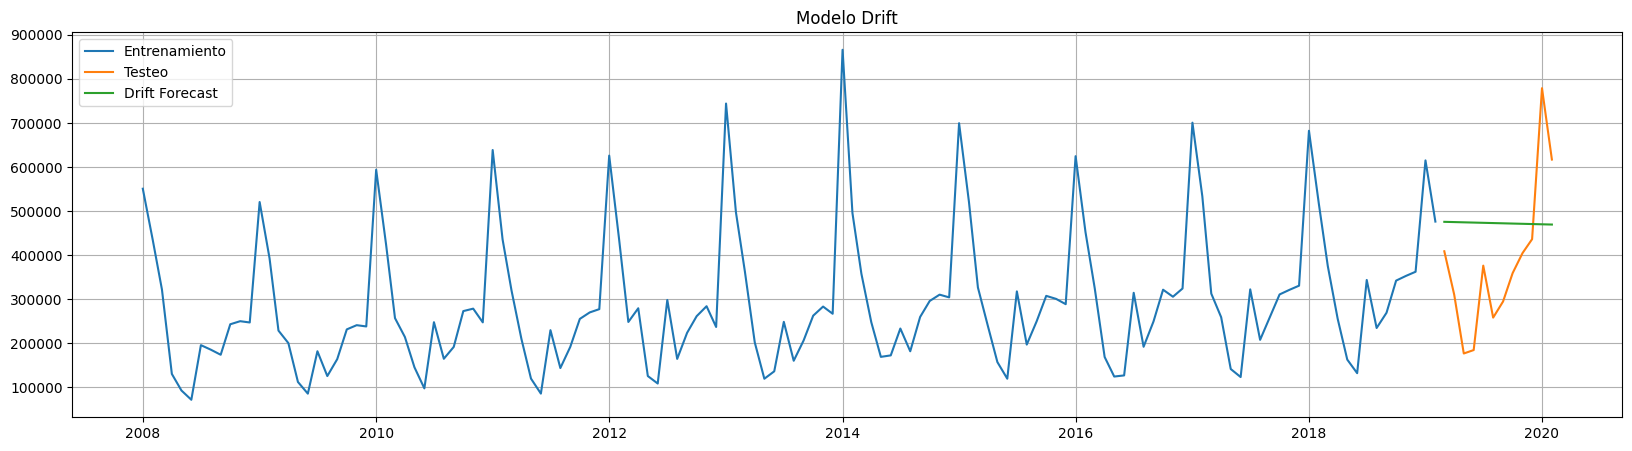

In [ ]:
# Crear figura con un tamaño adecuado
plt.figure(figsize=(20,5))
plt.grid()

# Graficar los datos de entrenamiento y test
plt.plot(train['total'], label='Entrenamiento')
plt.plot(test['total'], label='Testeo')

# Graficar el pronóstico de Drift
plt.plot(test['prediccion_Drift'], label='Drift Forecast')

# Añadir leyenda y título
plt.legend(loc='best')
plt.title('Modelo Drift')

# Mostrar la gráfica
plt.show()

In [ ]:
# Métricas del pronóstico a analizar posteriormente
from sklearn.metrics import mean_squared_error

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import math

# Métricas del pronóstico

MAE_DRIFT_METHOD = mean_absolute_error(
    test['total'],
    test['prediccion_Drift']
)

MSE_DRIFT_METHOD = mean_squared_error(
    test['total'],
    test['prediccion_Drift']
)

RMSE_DRIFT_METHOD = math.sqrt(MSE_DRIFT_METHOD)

MAPE_DRIFT_METHOD = mean_absolute_percentage_error(
    test['total'],
    test['prediccion_Drift']
)

Evaluación de la Performance del Pronóstico

- MAE (Error absoluto medio) calcula el promedio de las diferencias absolutas entre los valores predichos y los valores reales. Es una medida directa de cuán lejos, en promedio, están las predicciones del modelo de los resultados reales. Un MAE menor indica un modelo con mejores predicciones.
- RMSE (Error cuadrático medio) es una métrica que cuantifica la diferencia entre los valores predichos y los valores reales en un modelo de predicción. Se calcula como la raíz cuadrada de la media de los cuadrados de los errores. El RMSE es útil porque penaliza los errores grandes más severamente que el MAE, proporcionando una medida más sensible para las variaciones en los errores. Un RMSE más bajo indica un modelo que se ajusta mejor a los datos observados.
-MAPE (Error porcentual absoluto medio) es una métrica que calcula el error porcentual promedio entre los valores predichos y los valores reales. Es especialmente útil para evaluar la precisión relativa de un modelo en términos porcentuales, siendo menos sensible a valores atípicos que el RMSE.

In [ ]:
# Average Method

resultados_AV_METHOD = pd.DataFrame({'Metodo':['Average Method'],'MAE':[MAE_AV_METHOD] ,'RMSE': [RMSE_AV_METHOD], 'MAPE': [MAPE_AV_METHOD * 100]})
resultados_AV_METHOD = resultados_AV_METHOD[['Metodo', 'MAE','RMSE', 'MAPE']]

# Naïve Method

resultados_NAIVE_METHOD = pd.DataFrame({'Metodo':['Naïve Method'],'MAE':[MAE_NAIVE_METHOD] ,'RMSE': [RMSE_NAIVE_METHOD], 'MAPE': [MAPE_NAIVE_METHOD * 100]})
resultados_NAIVE_METHOD = resultados_NAIVE_METHOD[['Metodo', 'MAE','RMSE', 'MAPE']]

# Naive estacional

resultados_NAIVE_ESTACIONAL_METHOD = pd.DataFrame({'Metodo':['Seasonal Naïve Method'],'MAE':[MAE_NAIVE_ESTACIONAL_METHOD] ,'RMSE': [RMSE_NAIVE_ESTACIONAL_METHOD], 'MAPE': [MAPE_NAIVE_ESTACIONAL_METHOD * 100]})
resultados_NAIVE_ESTACIONAL_METHOD = resultados_NAIVE_ESTACIONAL_METHOD[['Metodo', 'MAE','RMSE', 'MAPE']]

# Metodo Drift

resultados_DRIFT_METHOD = pd.DataFrame({'Metodo':['Drift Method'],'MAE':[MAE_DRIFT_METHOD] ,'RMSE': [RMSE_DRIFT_METHOD], 'MAPE': [MAPE_DRIFT_METHOD * 100]})

In [ ]:
resultados = pd.concat([resultados_AV_METHOD, resultados_NAIVE_METHOD, resultados_NAIVE_ESTACIONAL_METHOD, resultados_DRIFT_METHOD], ignore_index=True)

print(resultados)

                  Metodo            MAE           RMSE       MAPE
0         Average Method  135798.741294     368.508808  32.599905
1           Naïve Method  166393.666667     407.913798  57.663877
2  Seasonal Naïve Method   56999.083333     238.744808  13.921661
3           Drift Method  164897.205514  188615.601543  57.000743


Graficos de las metricas

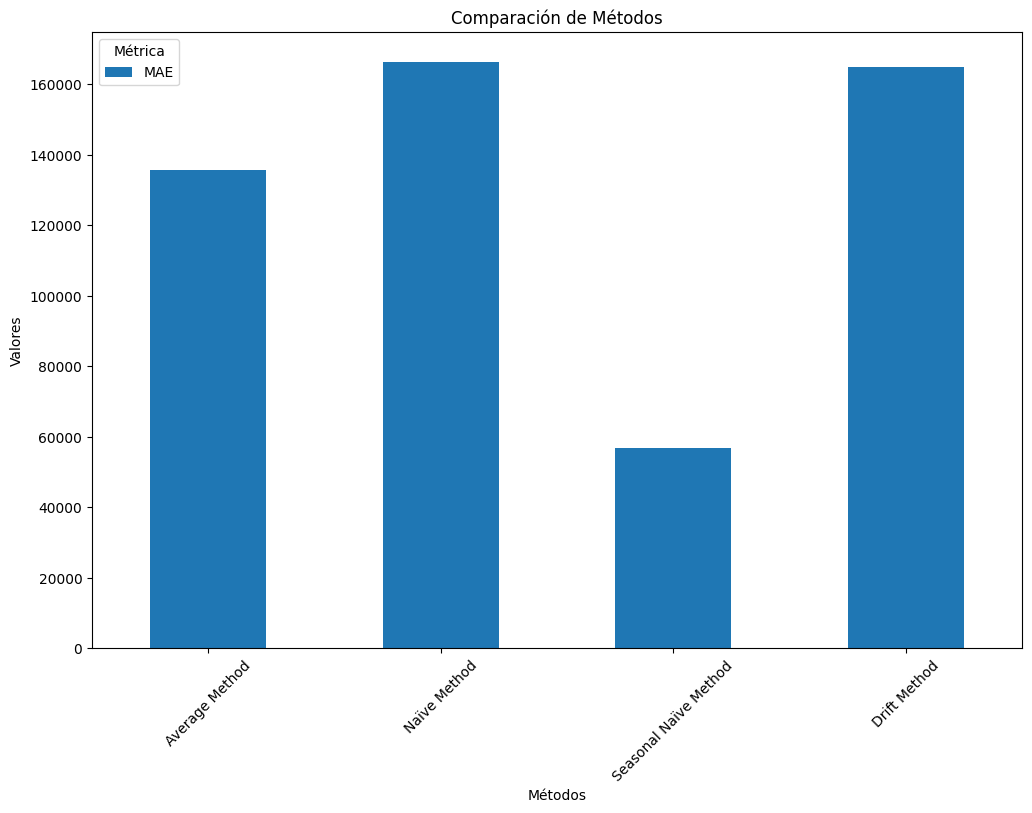

In [ ]:
columnas_a_mostrar = ['Metodo', 'MAE']
resultados_mostrar = resultados[columnas_a_mostrar]

resultados_mostrar.plot(kind='bar', x='Metodo', figsize=(12, 8))

plt.xlabel('Métodos')
plt.ylabel('Valores')
plt.title('Comparación de Métodos')
plt.xticks(rotation=45)
plt.legend(title='Métrica')
plt.show()

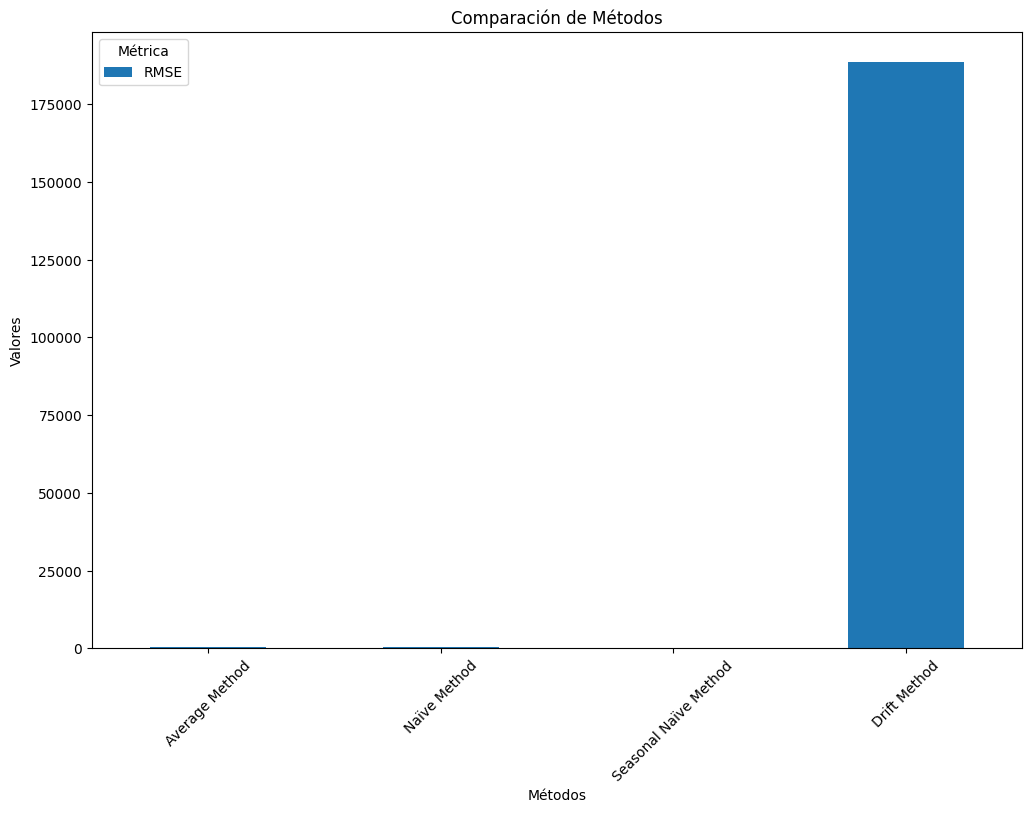

In [ ]:
columnas_a_mostrar = ['Metodo', 'RMSE']
resultados_mostrar = resultados[columnas_a_mostrar]

resultados_mostrar.plot(kind='bar', x='Metodo', figsize=(12, 8))

plt.xlabel('Métodos')
plt.ylabel('Valores')
plt.title('Comparación de Métodos')
plt.xticks(rotation=45)
plt.legend(title='Métrica')
plt.show()

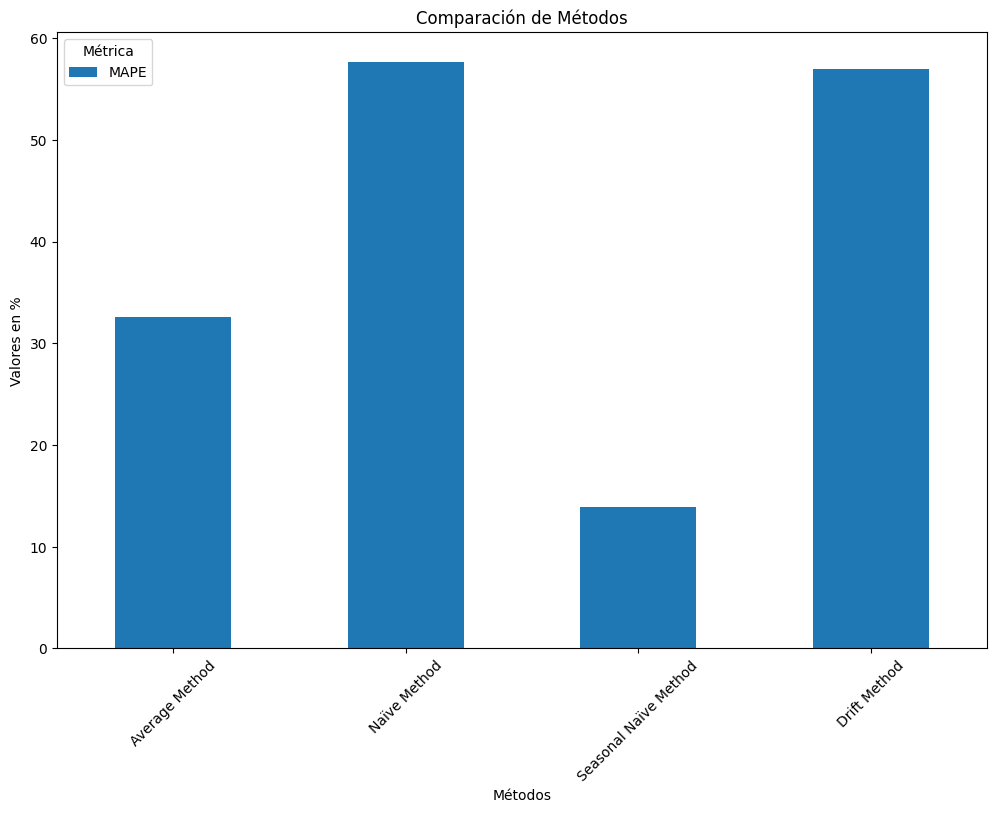

In [ ]:
columnas_a_mostrar = ['Metodo', 'MAPE']
resultados_mostrar = resultados[columnas_a_mostrar]

resultados_mostrar.plot(kind='bar', x='Metodo', figsize=(12, 8))

plt.xlabel('Métodos')
plt.ylabel('Valores en %')
plt.title('Comparación de Métodos')
plt.xticks(rotation=45)
plt.legend(title='Métrica')
plt.show()

## Otros Métodos Simples de Forecasting

**Holt-Winters Exponential Smoothing:** método de pronóstico especialmente útil para series temporales que presentan nivel, tendencia y estacionalidad. El modelo actualiza estos tres componentes de forma recursiva mediante suavizado exponencial, asignando mayor importancia a las observaciones más recientes. A partir de la evolución estimada del nivel, la tendencia y el patrón estacional, proyecta los valores futuros de la serie.

La **suavización exponencial** es una forma de estimar el comportamiento de una serie dando más peso a los datos recientes y menos peso a los datos antiguos.

Puede utilizar componentes aditivos o multiplicativos, dependiendo de cómo se comporte la tendencia y la estacionalidad respecto del nivel de la serie.

In [ ]:
len(data)-12

134

In [ ]:
data.index = pd.DatetimeIndex(data.index)
data = data.asfreq('MS')

In [ ]:
#Divido la serie de tiempo en entrenamiento y testeo
train_len = len(data) - 12

train = data.iloc[:train_len].copy()
test = data.iloc[train_len:].copy()

In [ ]:
# 1. Tendencia aditiva + estacionalidad aditiva
modelo_aa = ExponentialSmoothing(
    train["total"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

# 2. Tendencia aditiva + estacionalidad multiplicativa
modelo_am = ExponentialSmoothing(
    train["total"],
    trend="add",
    seasonal="mul",
    seasonal_periods=12
).fit()

# 3. Tendencia multiplicativa + estacionalidad aditiva
modelo_ma = ExponentialSmoothing(
    train["total"],
    trend="mul",
    seasonal="add",
    seasonal_periods=12
).fit()

# 4. Tendencia multiplicativa + estacionalidad multiplicativa
modelo_mm = ExponentialSmoothing(
    train["total"],
    trend="mul",
    seasonal="mul",
    seasonal_periods=12
).fit()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/holtwinters/model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)


In [ ]:
# Pronósticos a 12 meses

test_predictions_aa = modelo_aa.forecast(12)

test_predictions_am = modelo_am.forecast(12)

test_predictions_ma = modelo_ma.forecast(12)

test_predictions_mm = modelo_mm.forecast(12)

In [ ]:
test['HW_Add_Add'] = test_predictions_aa.values
test['HW_Add_Mul'] = test_predictions_am.values
test['HW_Mul_Add'] = test_predictions_ma.values
test['HW_Mul_Mul'] = test_predictions_mm.values

El ajuste de componentes (aditivo vs multiplicativo) depende del comportamiento de la serie en análisis:  

-Usar multiplicativo si los cambios (tendencia/estacionalidad) son proporcionales al nivel.  
-Usar aditivo si los cambios son constantes a lo largo del tiempo.

In [ ]:
prediccion_aa = test_predictions_aa.to_list()
prediccion_am = test_predictions_am.to_list()
prediccion_ma = test_predictions_ma.to_list()
prediccion_mm = test_predictions_mm.to_list()

In [ ]:
print(prediccion_aa)
print(prediccion_am)
print(prediccion_ma)
print(prediccion_mm)

[361384.87789367046, 271620.43397841766, 182128.0520198115, 162550.83882444166, 325653.6474520556, 230818.91814817808, 276133.82599288004, 337679.2425858465, 344691.2585436705, 342354.25046735944, 705166.9404546176, 529968.2211570562]
[356177.8219012818, 248234.58133609736, 153132.53144987844, 132597.38290131936, 322855.66873365367, 210007.2725119357, 257759.6682357117, 319997.87912835815, 324946.5646989779, 326785.663864156, 676909.9407346509, 519754.47988033347]
[364598.3346893955, 274584.8254033567, 185227.99811850605, 165824.77354696044, 329499.52816016757, 234430.39591918222, 279989.9442354662, 341612.0258824799, 348708.2248959434, 346602.4008322332, 709320.5693936097, 535013.9304882204]
[360443.8265470045, 251717.32060225678, 156365.4293912296, 135429.7088772598, 334613.37067116966, 219938.72365612266, 269849.1636908683, 336062.0604181357, 342377.98003875837, 347770.3118139033, 698855.421711081, 544682.6962121283]


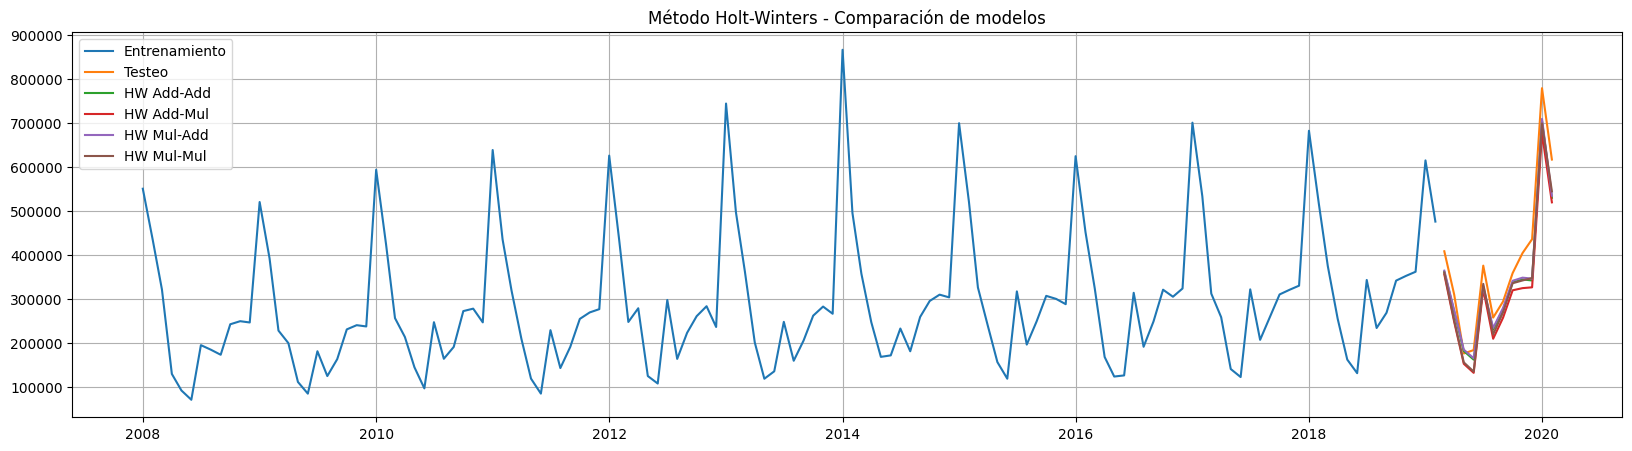

In [ ]:
# Agrego las predicciones al dataframe de test
test['prediccion_HW_AA'] = np.array(prediccion_aa)
test['prediccion_HW_AM'] = np.array(prediccion_am)
test['prediccion_HW_MA'] = np.array(prediccion_ma)
test['prediccion_HW_MM'] = np.array(prediccion_mm)

# Gráfico
plt.figure(figsize=(20,5))

plt.grid()

plt.plot(train['total'], label='Entrenamiento')

plt.plot(test['total'], label='Testeo')

plt.plot(test['prediccion_HW_AA'], label='HW Add-Add')
plt.plot(test['prediccion_HW_AM'], label='HW Add-Mul')
plt.plot(test['prediccion_HW_MA'], label='HW Mul-Add')
plt.plot(test['prediccion_HW_MM'], label='HW Mul-Mul')

plt.legend(loc='best')

plt.title('Método Holt-Winters - Comparación de modelos')

plt.show()

In [ ]:
# =========================
# MÉTRICAS HOLT-WINTERS
# =========================

# HW Additive - Additive
MAE_HW_AA = mean_absolute_error(test['total'], test['prediccion_HW_AA'])
MSE_HW_AA = mean_squared_error(test['total'], test['prediccion_HW_AA'])
RMSE_HW_AA = math.sqrt(MSE_HW_AA)
MAPE_HW_AA = mean_absolute_percentage_error(test['total'], test['prediccion_HW_AA'])


# HW Additive - Multiplicative
MAE_HW_AM = mean_absolute_error(test['total'], test['prediccion_HW_AM'])
MSE_HW_AM = mean_squared_error(test['total'], test['prediccion_HW_AM'])
RMSE_HW_AM = math.sqrt(MSE_HW_AM)
MAPE_HW_AM = mean_absolute_percentage_error(test['total'], test['prediccion_HW_AM'])


# HW Multiplicative - Additive
MAE_HW_MA = mean_absolute_error(test['total'], test['prediccion_HW_MA'])
MSE_HW_MA = mean_squared_error(test['total'], test['prediccion_HW_MA'])
RMSE_HW_MA = math.sqrt(MSE_HW_MA)
MAPE_HW_MA = mean_absolute_percentage_error(test['total'], test['prediccion_HW_MA'])


# HW Multiplicative - Multiplicative
MAE_HW_MM = mean_absolute_error(test['total'], test['prediccion_HW_MM'])
MSE_HW_MM = mean_squared_error(test['total'], test['prediccion_HW_MM'])
RMSE_HW_MM = math.sqrt(MSE_HW_MM)
MAPE_HW_MM = mean_absolute_percentage_error(test['total'], test['prediccion_HW_MM'])

In [ ]:
# Resultados Holt-Winters

resultados_HW = pd.DataFrame({
    'Metodo': [
        'HW Add-Add',
        'HW Add-Mul',
        'HW Mul-Add',
        'HW Mul-Mul'
    ],

    'MAE': [
        MAE_HW_AA,
        MAE_HW_AM,
        MAE_HW_MA,
        MAE_HW_MM
    ],

    'RMSE': [
        RMSE_HW_AA,
        RMSE_HW_AM,
        RMSE_HW_MA,
        RMSE_HW_MM
    ],

    'MAPE': [
        MAPE_HW_AA * 100,
        MAPE_HW_AM * 100,
        MAPE_HW_MA * 100,
        MAPE_HW_MM * 100
    ]
})

In [ ]:
resultados2 = pd.concat([
    resultados_AV_METHOD,
    resultados_NAIVE_METHOD,
    resultados_NAIVE_ESTACIONAL_METHOD,
    resultados_DRIFT_METHOD,
    resultados_HW
], ignore_index=True)

print(resultados2)

                  Metodo            MAE           RMSE       MAPE
0         Average Method  135798.741294     368.508808  32.599905
1           Naïve Method  166393.666667     407.913798  57.663877
2  Seasonal Naïve Method   56999.083333     238.744808  13.921661
3           Drift Method  164897.205514  188615.601543  57.000743
4             HW Add-Add   45400.966377   52979.966204  11.244844
5             HW Add-Mul   62883.378719   68293.073929  16.982801
6             HW Mul-Add   42145.753723   49628.101966  10.419176
7             HW Mul-Mul   50471.165531   54882.733968  13.893711


In [ ]:
resultados2 = resultados2.sort_values('RMSE').reset_index(drop=True)

print(resultados2.round(2))

                  Metodo        MAE       RMSE   MAPE
0  Seasonal Naïve Method   56999.08     238.74  13.92
1         Average Method  135798.74     368.51  32.60
2           Naïve Method  166393.67     407.91  57.66
3             HW Mul-Add   42145.75   49628.10  10.42
4             HW Add-Add   45400.97   52979.97  11.24
5             HW Mul-Mul   50471.17   54882.73  13.89
6             HW Add-Mul   62883.38   68293.07  16.98
7           Drift Method  164897.21  188615.60  57.00
